In [1]:
import sys
print(sys.executable)

/Users/dipasmitadebroy/Documents/Artificial_Intelligence/ml_projects/movie-recommender/venv/bin/python


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib, warnings

warnings.filterwarnings("ignore")
%matplotlib inline

PROCESSED_DIR = "../data/processed/"
MODEL_DIR     = "../models/"
FIGURES_DIR   = "../reports/figures/"

print("✅ Imports done")

✅ Imports done


In [3]:
#load predictions and align to common test rows

test = pd.read_parquet(PROCESSED_DIR + "test.parquet")

svd_art = joblib.load(MODEL_DIR + "svd.joblib")
nmf_art = joblib.load(MODEL_DIR + "nmf.joblib")
ncf_art = joblib.load(MODEL_DIR + "ncf_meta.joblib")

# SVD & NMF cover all test rows
svd_preds = svd_art["preds"]
nmf_preds = nmf_art["preds"]

# NCF only covers a subset — fill full array with NaN then align
ncf_full  = np.full(len(test), np.nan)
ncf_full[ncf_art["test_index"]] = ncf_art["preds"]

# Keep only rows where all models have predictions
mask   = ~np.isnan(ncf_full)
y_true = test.loc[mask, "rating"].values

preds_store = {
    "SVD": svd_preds[mask],
    "NMF": nmf_preds[mask],
    "NCF": ncf_full[mask],
}

print(f"Aligned rows: {mask.sum():,}")

Aligned rows: 5,026,171


In [4]:
#Simple average ensemble

avg_preds = np.clip(np.mean(list(preds_store.values()), axis=0), 0.5, 5.0)

rmse_avg = np.sqrt(mean_squared_error(y_true, avg_preds))
mae_avg  = mean_absolute_error(y_true, avg_preds)
print(f"Simple Average → RMSE: {rmse_avg:.4f} | MAE: {mae_avg:.4f}")

Simple Average → RMSE: 0.7951 | MAE: 0.5992


In [5]:
#optimized weights ensemble

model_names = list(preds_store.keys())
P           = np.column_stack(list(preds_store.values()))

result = minimize(
    lambda w: np.sqrt(mean_squared_error(y_true, P @ w)),
    x0=np.ones(len(model_names)) / len(model_names),
    method="SLSQP",
    bounds=[(0, 1)] * len(model_names),
    constraints={"type": "eq", "fun": lambda w: w.sum() - 1}
)

opt_weights = result.x
ens_preds   = np.clip(P @ opt_weights, 0.5, 5.0)
rmse_ens    = np.sqrt(mean_squared_error(y_true, ens_preds))
mae_ens     = mean_absolute_error(y_true, ens_preds)

print("⚖️  Optimized Weights:")
for name, w in zip(model_names, opt_weights):
    print(f"   {name}: {w:.4f}")
print(f"\nWeighted Ensemble → RMSE: {rmse_ens:.4f} | MAE: {mae_ens:.4f}")

ens_results = {"model": "WeightedEnsemble", "RMSE": rmse_ens, "MAE": mae_ens}

⚖️  Optimized Weights:
   SVD: 0.6597
   NMF: 0.0549
   NCF: 0.2855

Weighted Ensemble → RMSE: 0.7859 | MAE: 0.5901


In [6]:
#Stacking ensemble (Ridge Meta-Model)

split = int(len(y_true) * 0.8)
meta  = Ridge(alpha=1.0)
meta.fit(P[:split], y_true[:split])

stack_preds = np.clip(meta.predict(P[split:]), 0.5, 5.0)
rmse_stack  = np.sqrt(mean_squared_error(y_true[split:], stack_preds))
mae_stack   = mean_absolute_error(y_true[split:], stack_preds)

print(f"Stacking Ensemble  → RMSE: {rmse_stack:.4f} | MAE: {mae_stack:.4f}")
print(f"Meta-model coefs   : {dict(zip(model_names, meta.coef_.round(4)))}")

stack_results = {"model": "StackingEnsemble", "RMSE": rmse_stack, "MAE": mae_stack}

Stacking Ensemble  → RMSE: 0.7863 | MAE: 0.5917
Meta-model coefs   : {'SVD': 0.6545, 'NMF': 0.0513, 'NCF': 0.2917}


In [7]:
#final leaderboard

leaderboard = pd.read_csv("../reports/leaderboard.csv", index_col="model")

extras = pd.DataFrame([
    {"model": "SimpleAvg",        "RMSE": rmse_avg,   "MAE": mae_avg},
    {"model": "WeightedEnsemble", "RMSE": rmse_ens,   "MAE": mae_ens},
    {"model": "StackingEnsemble", "RMSE": rmse_stack, "MAE": mae_stack},
]).set_index("model")

final = pd.concat([leaderboard, extras]).sort_values("RMSE")

print("\n🏆 Final Leaderboard")
print("=" * 42)
print(final.to_string())
print("=" * 42)
print(f"\n🥇 Best: {final['RMSE'].idxmin()} (RMSE={final['RMSE'].min():.4f})")

final.to_csv("../reports/final_leaderboard.csv")


🏆 Final Leaderboard
                      RMSE       MAE
model                               
WeightedEnsemble  0.785856  0.590062
StackingEnsemble  0.786326  0.591659
SVD               0.792666  0.594850
SimpleAvg         0.795090  0.599204
NCF               0.824505  0.620201
NMF               0.887279  0.668919
UserCF            0.962862  0.744336
ALS               1.395611  1.035706

🥇 Best: WeightedEnsemble (RMSE=0.7859)


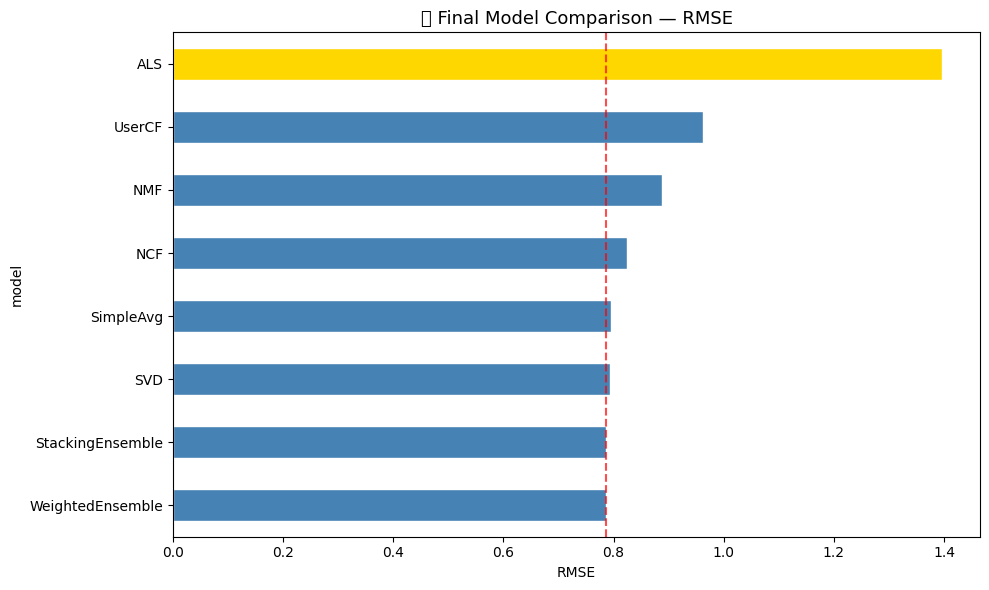

In [8]:
#final chart

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["gold" if i == 0 else "steelblue" for i in range(len(final))]
final["RMSE"].sort_values().plot(kind="barh", ax=ax, color=colors[::-1], edgecolor="white")
ax.set_title("🏆 Final Model Comparison — RMSE", fontsize=13)
ax.set_xlabel("RMSE")
ax.axvline(final["RMSE"].min(), color="red", ls="--", alpha=0.7)
plt.tight_layout()
plt.savefig(FIGURES_DIR + "final_leaderboard.png", dpi=150)
plt.show()

In [10]:
#Save Final Ensemble

joblib.dump({
    "model_names": model_names,
    "opt_weights": opt_weights,
    "meta_model": meta,
}, MODEL_DIR + "final_ensemble.joblib")

print("✅ Everything saved!")
print("📁 Outputs in: reports/figures/ and reports/*.csv")


✅ Everything saved!
📁 Outputs in: reports/figures/ and reports/*.csv


In [11]:
print("=" * 50)
print("🎬 MOVIE RECOMMENDER — FINAL RESULTS")
print("=" * 50)

# Dataset stats
print("\n📊 DATASET")
print(f"  Total ratings : {len(ratings):,}")
print(f"  Unique users  : {ratings['userId'].nunique():,}")
print(f"  Unique movies : {ratings['movieId'].nunique():,}")

# All model results
print("\n🏆 LEADERBOARD")
print(f"  {'Model':<22} {'RMSE':>6}  {'MAE':>6}")
print(f"  {'-'*38}")
print(f"  {'UserCF (Baseline)':<22} {rmse_base:>6.4f}  {mae_base:>6.4f}")
print(f"  {'SVD':<22} {rmse_t:>6.4f}  {mae_t:>6.4f}")
print(f"  {'NMF':<22} {rmse_nmf:>6.4f}  {mae_nmf:>6.4f}")
print(f"  {'NCF (Colab GPU)':<22} {rmse_ncf:>6.4f}  {mae_ncf:>6.4f}")
print(f"  {'ALS (Colab CPU)':<22} {rmse_als:>6.4f}  {mae_als:>6.4f}")
print(f"  {'Simple Average':<22} {rmse_avg:>6.4f}  {mae_avg:>6.4f}")
print(f"  {'Weighted Ensemble':<22} {rmse_ens:>6.4f}  {mae_ens:>6.4f}")
print(f"  {'Stacking Ensemble':<22} {rmse_stack:>6.4f}  {mae_stack:>6.4f}")

# Best model
print(f"\n🥇 BEST MODEL : {final['RMSE'].idxmin()}")
print(f"   RMSE       : {final['RMSE'].min():.4f}")
print(f"   MAE        : {final['MAE'].min():.4f}")

# Training notes
print("\n⚙️  TRAINING NOTES")
print(f"  SVD epochs        : 20")
print(f"  NMF epochs        : 50")
print(f"  NCF epochs        : 3 (Google Colab T4 GPU)")
print(f"  ALS iterations    : 10 (Google Colab CPU)")
print(f"  NCF batch size    : 1024")
print(f"  ALS factors       : 50")
print("=" * 50)

🎬 MOVIE RECOMMENDER — FINAL RESULTS

📊 DATASET


NameError: name 'ratings' is not defined